# Deep FCNN on Tiny ImageNet
**Author**: Deadlyharbor aka Aman Gupta and Vansh Pandey

## Task Description - 3.1 & 3.2
- Dataset: Tiny ImageNet (10 classes subset)
- Model: Deep FCNN (8 layers)
- **Task 3.1** Experiments:
    - Exp A: Sigmoid, No Batch Norm
    - Exp B: Leaky ReLU (0.01), Batch Norm
- **Task 3.2** Switch-Off Tests:
    1. Remove Dropout
    2. Learning Rate: 10x higher & 10x lower
    3. Adam vs Vanilla SGD
- Optimizer: AdamW (except for SGD experiment)

## Expectations in 3.1
- Small gradient norms and VGP in sigmoid activation function as NN is deep
- Learning occurs while relu is used with batch normalization as there will be no VGP.
- FCNN is used for images so overfitting without dropout is expected in task 1.
- Simplifiying the network architecture to lesser n[l] per layer may also reduce overfitting 
- Speed of training in relu will be faster due to reduce exponential operations

In [1]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import ImageFolder
import pandas as pd

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check CUDA
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device Name: {torch.cuda.get_device_name(0)}")

PyTorch Version: 2.6.0+cpu
CUDA Available: False


## 1. Data Parsing and Utils

In [2]:
def get_data_loaders(data_dir, batch_size=64):
    # Standard transformation for Tiny ImageNet (64x64)
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    # Standard Tiny ImageNet structure: 'train' and 'val' folders
    train_dir = os.path.join(data_dir, 'tiny-imagenet', 'train')
    val_dir = os.path.join(data_dir, 'tiny-imagenet', 'val')  
    test_dir = os.path.join(data_dir, 'tiny-imagenet', 'test')  
    if not os.path.exists(train_dir) or not os.path.exists(val_dir) or not os.path.exists(test_dir):
        print(f"Hey change this path carefully - {data_dir}/tiny-imagenet")
        return None, None

    # Load datasets directly from folders
    train_dataset = ImageFolder(root=train_dir, transform=transform)
    val_dataset = ImageFolder(root=val_dir, transform=transform)
    test_dataset = ImageFolder(root=test_dir, transform=transform)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    
    print(f"Classes: {train_dataset.classes}")
    print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}, Test size: {len(test_dataset)}")
    
    return train_loader, val_loader, test_loader

# Constants
DATA_DIR = 'C:\\Users\\Vansh\\Desktop\\DeepLearning-Project\\dataset'
BATCH_SIZE = 64
NUM_CLASSES = 10
INPUT_DIM = 64 * 64 * 3  # 12288

## 2. Network Architecture

In [3]:
class DeepFCNN(nn.Module):
    def __init__(self, activation='sigmoid', use_batch_norm=False, dropout_rate=0.0):
        super(DeepFCNN, self).__init__()
        self.use_batch_norm = use_batch_norm
        self.layers = nn.ModuleList()
        
        # Architecture: 12288 -> 512, 256, 256, 128, 128, 64, 32 -> 10
        dims = [INPUT_DIM, 512, 256, 256, 128, 128, 64, 32, NUM_CLASSES]
        
        for i in range(len(dims) - 1):
            self.layers.append(nn.Linear(dims[i], dims[i+1]))
            
            # Add activation and BN for all except last layer
            if i < len(dims) - 2:
                if use_batch_norm:
                    self.layers.append(nn.BatchNorm1d(dims[i+1]))
                
                if activation == 'sigmoid':
                    self.layers.append(nn.Sigmoid())
                elif activation == 'leaky_relu':
                    self.layers.append(nn.LeakyReLU(0.01))
                
                # Add dropout if specified
                if dropout_rate > 0:
                    self.layers.append(nn.Dropout(dropout_rate))
        
    def forward(self, x):
        x = x.view(x.size(0), -1)
        for layer in self.layers:
            x = layer(x)
        return x

## 3. Training Loop & Utils

In [4]:
def train_model(model, train_loader, val_loader, epochs=20, lr=0.001, optimizer_type='adam', device='cuda'):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    
    # Select optimizer
    if optimizer_type == 'adam':
        optimizer = optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.999), eps=1e-8)
    elif optimizer_type == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.0)  # Vanilla SGD
    
    history = {
        'train_loss': [], 'val_loss': [], 'val_acc': [],
        'layer1_grad_norm': [], 'time_per_epoch': []
    }
    
    print(f"Starting training on {device}...")
    
    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        running_loss = 0.0
        
        # Track gradient norm for first layer
        epoch_grad_norms = []
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            
            # Capture grad norm of first linear layer
            first_layer_grad = model.layers[0].weight.grad.norm().item()
            epoch_grad_norms.append(first_layer_grad)
            
            optimizer.step()
            running_loss += loss.item()
        
        epoch_time = time.time() - start_time
        avg_train_loss = running_loss / len(train_loader)
        avg_grad_norm = np.mean(epoch_grad_norms)
        
        # Validation
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        avg_val_loss = val_loss / len(val_loader)
        val_acc = 100 * correct / total
        
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)
        history['layer1_grad_norm'].append(avg_grad_norm)
        history['time_per_epoch'].append(epoch_time)
        
        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Time: {epoch_time:.2f}s "
              f"Train Loss: {avg_train_loss:.4f} "
              f"Val Loss: {avg_val_loss:.4f} "
              f"Val Acc: {val_acc:.2f}% "
              f"Grad Norm: {avg_grad_norm:.4f}")
              
    return history

In [5]:
def evaluate_test(model, test_loader, device='cuda'): 
    model.eval()
    criterion = nn.CrossEntropyLoss()
    
    test_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    avg_test_loss = test_loss / len(test_loader)
    test_acc = 100 * correct / total
    
    return avg_test_loss, test_acc

## 4. Task 3.1 - Run Experiments A & B

In [6]:
# Setup Data
train_loader, val_loader, test_loader = get_data_loaders(DATA_DIR, BATCH_SIZE)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if train_loader:
    # EXP A: Sigmoid, No Batch Norm
    print("\n--- Experiment A: Sigmoid ---")
    model_a = DeepFCNN(activation='sigmoid', use_batch_norm=False)
    history_a = train_model(model_a, train_loader, val_loader, epochs=20, device=device)

    # EXP B: Leaky ReLU + Batch Norm
    print("\n--- Experiment B: Leaky ReLU + BN ---")
    model_b = DeepFCNN(activation='leaky_relu', use_batch_norm=True)
    history_b = train_model(model_b, train_loader, val_loader, epochs=20, device=device)
else:
    print("Data loaders failed to initialize. Check path.")

Classes: ['n07871810', 'n07873807', 'n07875152', 'n07920052', 'n09193705', 'n09246464', 'n09256479', 'n09332890', 'n09428293', 'n12267677']
Train size: 3500, Val size: 500, Test size: 1000
Using device: cpu

--- Experiment A: Sigmoid ---
Starting training on cpu...
Epoch [1/20] Time: 11.49s Train Loss: 2.3070 Val Loss: 2.2829 Val Acc: 17.40% Grad Norm: 0.0005
Epoch [2/20] Time: 15.70s Train Loss: 2.1888 Val Loss: 2.0877 Val Acc: 18.60% Grad Norm: 0.0296
Epoch [3/20] Time: 26.26s Train Loss: 2.0437 Val Loss: 2.0633 Val Acc: 18.00% Grad Norm: 0.1760
Epoch [4/20] Time: 12.10s Train Loss: 1.9970 Val Loss: 2.0068 Val Acc: 19.20% Grad Norm: 0.0991
Epoch [5/20] Time: 12.09s Train Loss: 1.9727 Val Loss: 1.9889 Val Acc: 19.20% Grad Norm: 0.2260
Epoch [6/20] Time: 11.97s Train Loss: 1.9742 Val Loss: 2.0571 Val Acc: 19.00% Grad Norm: 0.1508
Epoch [7/20] Time: 12.31s Train Loss: 1.9845 Val Loss: 2.0219 Val Acc: 19.00% Grad Norm: 0.2022
Epoch [8/20] Time: 12.05s Train Loss: 1.9661 Val Loss: 1.9855 

## 5. Task 3.1 - Plot Results

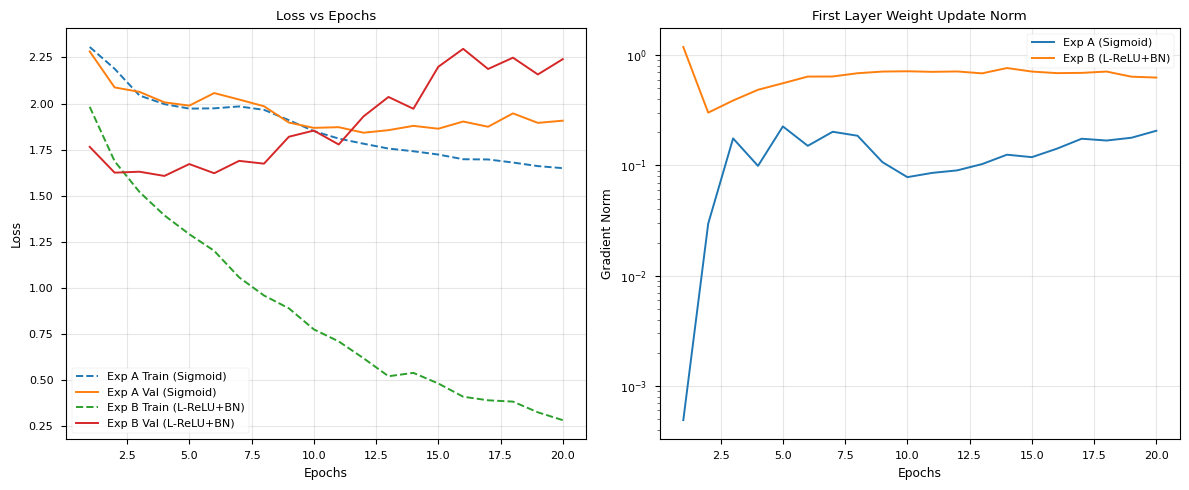

Task 3.1 Plots saved to plots/comparison_plot_3_1.png


In [7]:
os.makedirs('plots', exist_ok=True)

if train_loader:
    epochs = range(1, 21)

    # Plot Loss Comparison
    plt.figure(figsize=(12, 5))
    plt.style.use('seaborn-v0_8-paper')
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_a['train_loss'], label='Exp A Train (Sigmoid)', linestyle='--')
    plt.plot(epochs, history_a['val_loss'], label='Exp A Val (Sigmoid)')
    plt.plot(epochs, history_b['train_loss'], label='Exp B Train (L-ReLU+BN)', linestyle='--')
    plt.plot(epochs, history_b['val_loss'], label='Exp B Val (L-ReLU+BN)')
    plt.title('Loss vs Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot Gradient Norms
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_a['layer1_grad_norm'], label='Exp A (Sigmoid)')
    plt.plot(epochs, history_b['layer1_grad_norm'], label='Exp B (L-ReLU+BN)')
    plt.title('First Layer Weight Update Norm')
    plt.xlabel('Epochs')
    plt.ylabel('Gradient Norm')
    plt.yscale('log')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('plots/comparison_plot_3_1.png', dpi=300)
    plt.show()
    
    print("Task 3.1 Plots saved to plots/comparison_plot_3_1.png")

# Task 3.2 - Switch-Off Tests

## Baseline Configuration (for comparison)
- Activation: Leaky ReLU (0.01)
- Batch Normalization: Yes
- Dropout: 0.3 (baseline)
- Learning Rate: 0.001
- Optimizer: AdamW

In [8]:
switch_off_results = []

if train_loader: 
    print("BASELINE: L-ReLU + BN + Dropout(0.3) + LR=0.001 + Adam")
    model_baseline = DeepFCNN(activation='leaky_relu', use_batch_norm=True, dropout_rate=0.3)
    history_baseline = train_model(model_baseline, train_loader, val_loader, epochs=20, 
                                   lr=0.001, optimizer_type='adam', device=device)
    final_val_acc_baseline = history_baseline['val_acc'][-1] 
    test_loss_baseline, test_acc_baseline = evaluate_test(model_baseline, test_loader, device)
    
    switch_off_results.append({
        'Configuration': 'Baseline (L-ReLU + BN + Dropout 0.3 + LR 0.001 + Adam)',
        'Final Val Acc (%)': f"{final_val_acc_baseline:.2f}",
        'Final Test Acc (%)': f"{test_acc_baseline:.2f}"
    })
    print(f"Baseline Final Val Accuracy: {final_val_acc_baseline:.2f}%")
    print(f"Baseline Final Test Accuracy: {test_acc_baseline:.2f}%")
    print(f"Baseline Test Loss: {test_loss_baseline:.4f}\n")

BASELINE: L-ReLU + BN + Dropout(0.3) + LR=0.001 + Adam
Starting training on cpu...
Epoch [1/20] Time: 9.53s Train Loss: 2.3149 Val Loss: 2.1294 Val Acc: 28.00% Grad Norm: 1.2177
Epoch [2/20] Time: 9.31s Train Loss: 2.1082 Val Loss: 1.9033 Val Acc: 33.40% Grad Norm: 0.2275
Epoch [3/20] Time: 9.29s Train Loss: 1.9295 Val Loss: 1.7367 Val Acc: 36.20% Grad Norm: 0.2056
Epoch [4/20] Time: 9.21s Train Loss: 1.7981 Val Loss: 1.6592 Val Acc: 35.60% Grad Norm: 0.2556
Epoch [5/20] Time: 9.63s Train Loss: 1.7228 Val Loss: 1.6750 Val Acc: 36.00% Grad Norm: 0.2954
Epoch [6/20] Time: 9.84s Train Loss: 1.6615 Val Loss: 1.6317 Val Acc: 36.20% Grad Norm: 0.3278
Epoch [7/20] Time: 9.26s Train Loss: 1.6034 Val Loss: 1.6096 Val Acc: 37.80% Grad Norm: 0.3558
Epoch [8/20] Time: 9.09s Train Loss: 1.6046 Val Loss: 1.6201 Val Acc: 37.40% Grad Norm: 0.3927
Epoch [9/20] Time: 15.95s Train Loss: 1.5243 Val Loss: 1.6153 Val Acc: 37.40% Grad Norm: 0.3901
Epoch [10/20] Time: 9.47s Train Loss: 1.5063 Val Loss: 1.6132

## Switch-Off Test 1: Remove Dropout

In [9]:
if train_loader:
    print("SWITCH-OFF Test 1: No Dropout")
    model_no_dropout = DeepFCNN(activation='leaky_relu', use_batch_norm=True, dropout_rate=0.0)
    history_no_dropout = train_model(model_no_dropout, train_loader, val_loader, epochs=20,
                                     lr=0.001, optimizer_type='adam', device=device)
    final_val_acc_no_dropout = history_no_dropout['val_acc'][-1] 
    test_loss_no_dropout, test_acc_no_dropout = evaluate_test(model_no_dropout, test_loader, device)
    
    switch_off_results.append({
        'Configuration': 'No Dropout (L-ReLU + BN + LR 0.001 + Adam)',
        'Final Val Acc (%)': f"{final_val_acc_no_dropout:.2f}",
        'Final Test Acc (%)': f"{test_acc_no_dropout:.2f}"
    })
    print(f"No Dropout Final Val Accuracy: {final_val_acc_no_dropout:.2f}%")
    print(f"No Dropout Final Test Accuracy: {test_acc_no_dropout:.2f}%")
    print(f"No Dropout Test Loss: {test_loss_no_dropout:.4f}\n")

SWITCH-OFF Test 1: No Dropout
Starting training on cpu...
Epoch [1/20] Time: 10.86s Train Loss: 1.9703 Val Loss: 1.7673 Val Acc: 33.00% Grad Norm: 1.1501
Epoch [2/20] Time: 9.15s Train Loss: 1.6678 Val Loss: 1.6356 Val Acc: 37.00% Grad Norm: 0.2780
Epoch [3/20] Time: 9.03s Train Loss: 1.5297 Val Loss: 1.6029 Val Acc: 41.00% Grad Norm: 0.4021
Epoch [4/20] Time: 9.12s Train Loss: 1.4246 Val Loss: 1.5876 Val Acc: 42.40% Grad Norm: 0.4649
Epoch [5/20] Time: 9.31s Train Loss: 1.3161 Val Loss: 1.6352 Val Acc: 42.40% Grad Norm: 0.5558
Epoch [6/20] Time: 8.88s Train Loss: 1.1769 Val Loss: 1.6342 Val Acc: 41.60% Grad Norm: 0.6222
Epoch [7/20] Time: 9.07s Train Loss: 1.1131 Val Loss: 1.5882 Val Acc: 42.40% Grad Norm: 0.6287
Epoch [8/20] Time: 8.87s Train Loss: 0.9815 Val Loss: 1.6144 Val Acc: 45.20% Grad Norm: 0.7188
Epoch [9/20] Time: 8.86s Train Loss: 0.8528 Val Loss: 1.7930 Val Acc: 41.80% Grad Norm: 0.6931
Epoch [10/20] Time: 8.97s Train Loss: 0.7817 Val Loss: 1.7738 Val Acc: 43.80% Grad Nor

## Switch-Off Test 2a: Learning Rate 10x Higher (0.01)

In [10]:
if train_loader:
    print("SWITCH-OFF Test 2a: LR = 0.01 (10x higher)")
    model_lr_high = DeepFCNN(activation='leaky_relu', use_batch_norm=True, dropout_rate=0.3)
    history_lr_high = train_model(model_lr_high, train_loader, val_loader, epochs=20,
                                  lr=0.01, optimizer_type='adam', device=device)
    final_val_acc_lr_high = history_lr_high['val_acc'][-1] 
    test_loss_lr_high, test_acc_lr_high = evaluate_test(model_lr_high, test_loader, device)
    
    switch_off_results.append({
        'Configuration': 'LR = 0.01 (10x higher)',
        'Final Val Acc (%)': f"{final_val_acc_lr_high:.2f}",
        'Final Test Acc (%)': f"{test_acc_lr_high:.2f}"
    })
    print(f"LR 0.01 Final Val Accuracy: {final_val_acc_lr_high:.2f}%")
    print(f"LR 0.01 Final Test Accuracy: {test_acc_lr_high:.2f}%")
    print(f"LR 0.01 Test Loss: {test_loss_lr_high:.4f}\n")

SWITCH-OFF Test 2a: LR = 0.01 (10x higher)
Starting training on cpu...
Epoch [1/20] Time: 9.03s Train Loss: 2.0535 Val Loss: 1.7755 Val Acc: 27.20% Grad Norm: 0.4985
Epoch [2/20] Time: 9.15s Train Loss: 1.8272 Val Loss: 1.7055 Val Acc: 30.20% Grad Norm: 0.0312
Epoch [3/20] Time: 9.54s Train Loss: 1.7596 Val Loss: 1.7077 Val Acc: 31.80% Grad Norm: 0.0367
Epoch [4/20] Time: 9.42s Train Loss: 1.7198 Val Loss: 1.6564 Val Acc: 34.00% Grad Norm: 0.0501
Epoch [5/20] Time: 9.12s Train Loss: 1.6874 Val Loss: 1.6122 Val Acc: 35.80% Grad Norm: 0.0516
Epoch [6/20] Time: 9.04s Train Loss: 1.6285 Val Loss: 1.6236 Val Acc: 34.60% Grad Norm: 0.0641
Epoch [7/20] Time: 9.48s Train Loss: 1.6274 Val Loss: 1.5938 Val Acc: 36.80% Grad Norm: 0.0634
Epoch [8/20] Time: 9.15s Train Loss: 1.5998 Val Loss: 1.6088 Val Acc: 36.40% Grad Norm: 0.0613
Epoch [9/20] Time: 9.06s Train Loss: 1.5597 Val Loss: 1.5795 Val Acc: 40.60% Grad Norm: 0.0718
Epoch [10/20] Time: 9.48s Train Loss: 1.5346 Val Loss: 1.6034 Val Acc: 36.

## Switch-Off Test 2b: Learning Rate 10x Lower (0.0001)

In [11]:
if train_loader:
    print("SWITCH-OFF Test 2b: LR = 0.0001 (10x lower)")
    model_lr_low = DeepFCNN(activation='leaky_relu', use_batch_norm=True, dropout_rate=0.3)
    history_lr_low = train_model(model_lr_low, train_loader, val_loader, epochs=20,
                                 lr=0.0001, optimizer_type='adam', device=device)
    final_val_acc_lr_low = history_lr_low['val_acc'][-1] 
    test_loss_lr_low, test_acc_lr_low = evaluate_test(model_lr_low, test_loader, device)
    
    switch_off_results.append({
        'Configuration': 'LR = 0.0001 (10x lower)',
        'Final Val Acc (%)': f"{final_val_acc_lr_low:.2f}",
        'Final Test Acc (%)': f"{test_acc_lr_low:.2f}"
    })
    print(f"LR 0.0001 Final Val Accuracy: {final_val_acc_lr_low:.2f}%")
    print(f"LR 0.0001 Final Test Accuracy: {test_acc_lr_low:.2f}%")
    print(f"LR 0.0001 Test Loss: {test_loss_lr_low:.4f}\n")

SWITCH-OFF Test 2b: LR = 0.0001 (10x lower)
Starting training on cpu...
Epoch [1/20] Time: 8.93s Train Loss: 2.3653 Val Loss: 2.2549 Val Acc: 17.40% Grad Norm: 9.5700
Epoch [2/20] Time: 8.97s Train Loss: 2.3212 Val Loss: 2.2144 Val Acc: 24.40% Grad Norm: 5.2513
Epoch [3/20] Time: 8.94s Train Loss: 2.3047 Val Loss: 2.1817 Val Acc: 26.60% Grad Norm: 4.1673
Epoch [4/20] Time: 8.92s Train Loss: 2.2534 Val Loss: 2.1385 Val Acc: 27.80% Grad Norm: 3.4681
Epoch [5/20] Time: 9.10s Train Loss: 2.2179 Val Loss: 2.1151 Val Acc: 30.00% Grad Norm: 2.9632
Epoch [6/20] Time: 8.98s Train Loss: 2.1801 Val Loss: 2.0724 Val Acc: 33.60% Grad Norm: 2.5981
Epoch [7/20] Time: 9.03s Train Loss: 2.1490 Val Loss: 2.0497 Val Acc: 30.60% Grad Norm: 2.2811
Epoch [8/20] Time: 9.02s Train Loss: 2.1159 Val Loss: 2.0159 Val Acc: 31.60% Grad Norm: 2.1089
Epoch [9/20] Time: 9.12s Train Loss: 2.0967 Val Loss: 1.9833 Val Acc: 31.80% Grad Norm: 1.8912
Epoch [10/20] Time: 9.07s Train Loss: 2.0438 Val Loss: 1.9635 Val Acc: 31

## Switch-Off Test 3: Adam vs Vanilla SGD

In [12]:
if train_loader:
    print("SWITCH-OFF Test 3: Vanilla SGD (no momentum)")
    model_sgd = DeepFCNN(activation='leaky_relu', use_batch_norm=True, dropout_rate=0.3)
    history_sgd = train_model(model_sgd, train_loader, val_loader, epochs=20,
                             lr=0.001, optimizer_type='sgd', device=device)
    final_val_acc_sgd = history_sgd['val_acc'][-1] 
    test_loss_sgd, test_acc_sgd = evaluate_test(model_sgd, test_loader, device)
    
    switch_off_results.append({
        'Configuration': 'Vanilla SGD (L-ReLU + BN + Dropout 0.3 + LR 0.001)',
        'Final Val Acc (%)': f"{final_val_acc_sgd:.2f}",
        'Final Test Acc (%)': f"{test_acc_sgd:.2f}"
    })
    print(f"Vanilla SGD Final Val Accuracy: {final_val_acc_sgd:.2f}%")
    print(f"Vanilla SGD Final Test Accuracy: {test_acc_sgd:.2f}%")
    print(f"Vanilla SGD Test Loss: {test_loss_sgd:.4f}\n")

SWITCH-OFF Test 3: Vanilla SGD (no momentum)
Starting training on cpu...
Epoch [1/20] Time: 7.42s Train Loss: 2.3967 Val Loss: 2.2998 Val Acc: 9.60% Grad Norm: 24.3755
Epoch [2/20] Time: 7.49s Train Loss: 2.3745 Val Loss: 2.2968 Val Acc: 10.40% Grad Norm: 22.2956
Epoch [3/20] Time: 7.61s Train Loss: 2.3787 Val Loss: 2.2899 Val Acc: 9.60% Grad Norm: 20.5680
Epoch [4/20] Time: 7.32s Train Loss: 2.3577 Val Loss: 2.2836 Val Acc: 10.00% Grad Norm: 19.3449
Epoch [5/20] Time: 7.61s Train Loss: 2.3567 Val Loss: 2.2796 Val Acc: 10.40% Grad Norm: 18.6376
Epoch [6/20] Time: 7.36s Train Loss: 2.3514 Val Loss: 2.2761 Val Acc: 11.60% Grad Norm: 17.8342
Epoch [7/20] Time: 7.36s Train Loss: 2.3321 Val Loss: 2.2697 Val Acc: 11.40% Grad Norm: 16.8101
Epoch [8/20] Time: 8.98s Train Loss: 2.3226 Val Loss: 2.2688 Val Acc: 12.00% Grad Norm: 16.5314
Epoch [9/20] Time: 7.50s Train Loss: 2.3220 Val Loss: 2.2645 Val Acc: 12.40% Grad Norm: 15.9428
Epoch [10/20] Time: 7.41s Train Loss: 2.3362 Val Loss: 2.2600 Val

## Summary Table for Switch-Off Tests

In [13]:
if train_loader and test_loader: 
    df_results = pd.DataFrame(switch_off_results)
    print("\n" + "="*110)
    print("TASK 3.2 - SWITCH-OFF TESTS SUMMARY (VALIDATION & TEST ACCURACY)")
    print("="*110)
    print(df_results.to_string(index=False))
    print("="*110 + "\n")
    df_results.to_csv('plots/switch_off_results.csv', index=False)
    print("\nResults saved to plots/switch_off_results.csv")


TASK 3.2 - SWITCH-OFF TESTS SUMMARY (VALIDATION & TEST ACCURACY)
                                         Configuration Final Val Acc (%) Final Test Acc (%)
Baseline (L-ReLU + BN + Dropout 0.3 + LR 0.001 + Adam)             42.00              41.00
            No Dropout (L-ReLU + BN + LR 0.001 + Adam)             40.40              37.80
                                LR = 0.01 (10x higher)             36.40              38.70
                               LR = 0.0001 (10x lower)             37.40              34.70
    Vanilla SGD (L-ReLU + BN + Dropout 0.3 + LR 0.001)             19.00              20.80


Results saved to plots/switch_off_results.csv


## Comparative Plots for Task 3.2

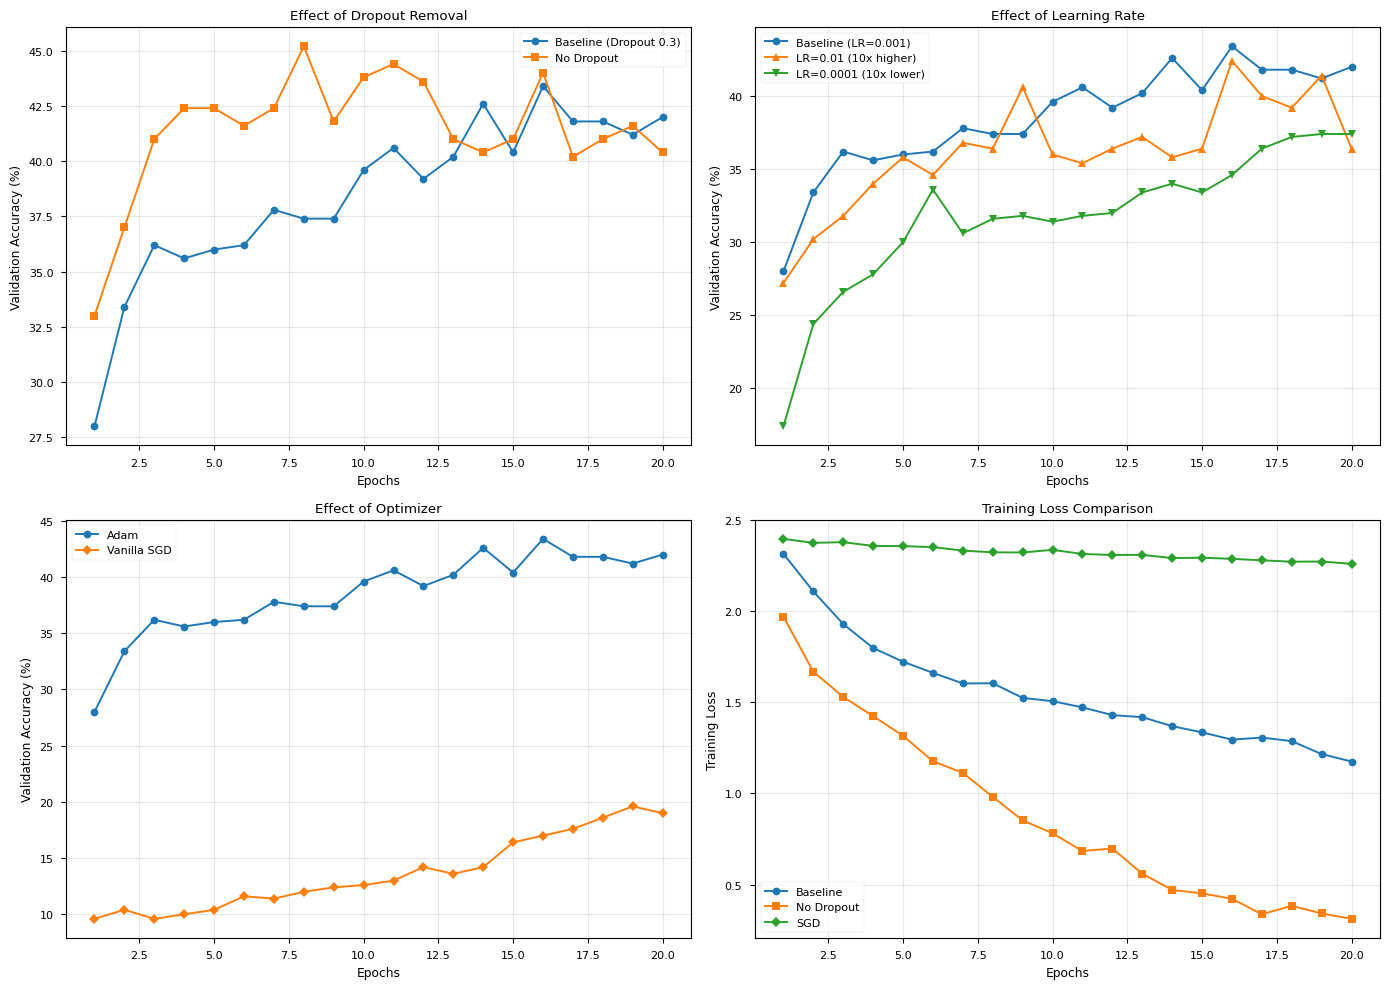

Switch-Off comparison plots saved to plots/switch_off_comparison.png


In [14]:
if train_loader:
    epochs = range(1, 21)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    plt.style.use('seaborn-v0_8-paper')
     
    axes[0, 0].plot(epochs, history_baseline['val_acc'], label='Baseline (Dropout 0.3)', marker='o')
    axes[0, 0].plot(epochs, history_no_dropout['val_acc'], label='No Dropout', marker='s')
    axes[0, 0].set_title('Effect of Dropout Removal')
    axes[0, 0].set_xlabel('Epochs')
    axes[0, 0].set_ylabel('Validation Accuracy (%)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
     
    axes[0, 1].plot(epochs, history_baseline['val_acc'], label='Baseline (LR=0.001)', marker='o')
    axes[0, 1].plot(epochs, history_lr_high['val_acc'], label='LR=0.01 (10x higher)', marker='^')
    axes[0, 1].plot(epochs, history_lr_low['val_acc'], label='LR=0.0001 (10x lower)', marker='v')
    axes[0, 1].set_title('Effect of Learning Rate')
    axes[0, 1].set_xlabel('Epochs')
    axes[0, 1].set_ylabel('Validation Accuracy (%)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
     
    axes[1, 0].plot(epochs, history_baseline['val_acc'], label='Adam', marker='o')
    axes[1, 0].plot(epochs, history_sgd['val_acc'], label='Vanilla SGD', marker='D')
    axes[1, 0].set_title('Effect of Optimizer')
    axes[1, 0].set_xlabel('Epochs')
    axes[1, 0].set_ylabel('Validation Accuracy (%)')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
     
    axes[1, 1].plot(epochs, history_baseline['train_loss'], label='Baseline', marker='o')
    axes[1, 1].plot(epochs, history_no_dropout['train_loss'], label='No Dropout', marker='s')
    axes[1, 1].plot(epochs, history_sgd['train_loss'], label='SGD', marker='D')
    axes[1, 1].set_title('Training Loss Comparison')
    axes[1, 1].set_xlabel('Epochs')
    axes[1, 1].set_ylabel('Training Loss')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('plots/switch_off_comparison.png', dpi=300)
    plt.show()
    
    print("Switch-Off comparison plots saved to plots/switch_off_comparison.png")